<a href="https://colab.research.google.com/github/Khanbir/Data_analitycs/blob/main/DZ2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib_ipynb_2%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DATA-ANALITICS_ Pylieva/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [ ]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,4,Saturday,5,52,2011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,19,Wednesday,2,51,2012,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,20,Wednesday,2,51,2012,19
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,21,Wednesday,2,51,2012,19


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

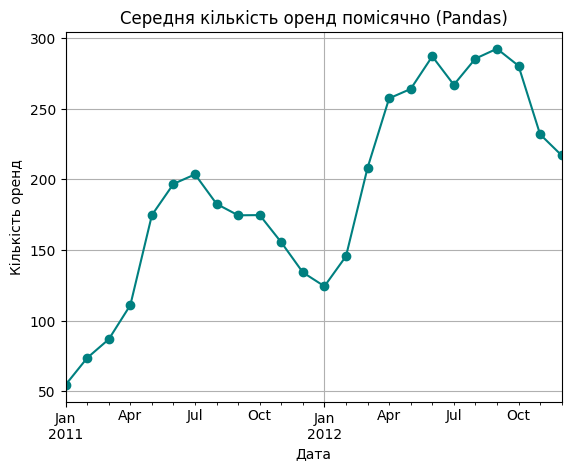

In [ ]:
##Варіант 1 — Pandas plot()
monthly_avg = df['count'].resample('ME').mean()
monthly_avg.plot(
    marker='o',
    color='teal',
    title='Середня кількість оренд помісячно (Pandas)',
    ylabel='Кількість оренд',
    xlabel='Дата'
)
plt.grid(True)
plt.show()

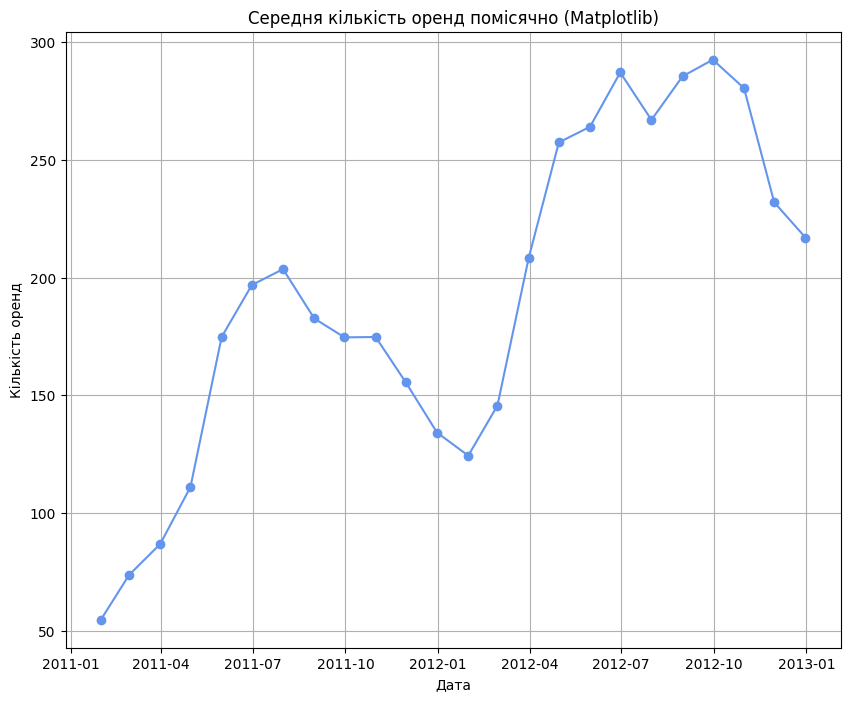

In [ ]:
##Варіант 2 — Matplotlib
plt.figure(figsize=(10, 8))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='cornflowerblue')
plt.title('Середня кількість оренд помісячно (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.show()

**Чим відрізняються 2 побудованих графіки? Який вам більше подобається?**

Варіант 1 — Pandas plot()
Переваги:
Код - короткий і локанічний
Швидко та зручно для типових візуалізацій.
Автоматично додає осі та заголовок.

Варіант 2 — Matplotlib
Переваги:
Повний контроль над зовнішнім виглядом.
Можна тонко налаштувати всі елементи графіка.

Код - більш деталізований, зато можна зробити більш витончену стилізацію.Висока гнучкість

Як на мій погляд - обидва методи виконують завдання чудово. Якщо ти робиш попередню розвідку — Pandas підійде ідеально. Якщо це частина бізнес-звіту або ти хочеш кастомну візуалізацію — Matplotlib дає потужну свободу дій.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

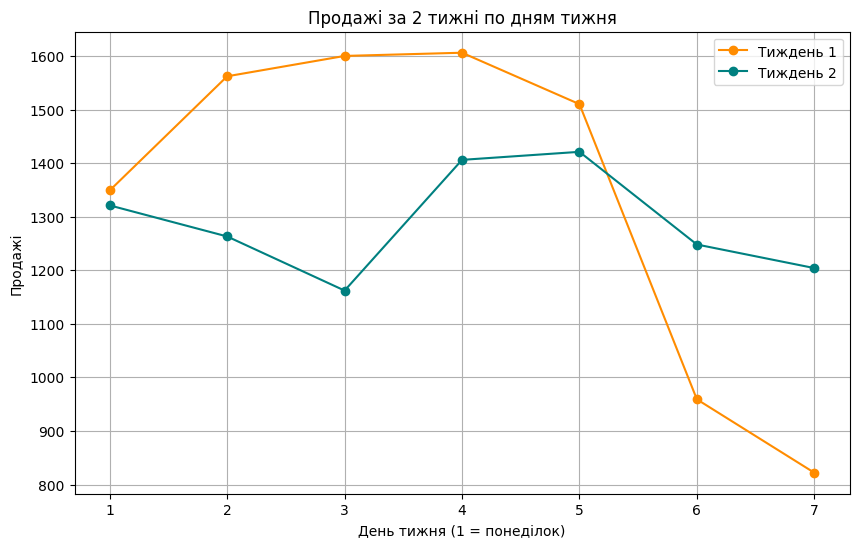

In [ ]:
import matplotlib.pyplot as plt

# Створення графіка
plt.figure(figsize=(10, 6))
plt.plot(days, sales_week1, marker='o', linestyle='-', color='darkorange', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', linestyle='-', color='teal', label='Тиждень 2')

# Додавання підписів та легенди
plt.title('Продажі за 2 тижні по дням тижня')
plt.xlabel('День тижня (1 = понеділок)')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
## Щоб зрозуміти стабільність, моя пропозиція порівняти стандартне відхилення для кожного тижня:
std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print("Стандартне відхилення:")
print(f"Тиждень 1: {std_week1:.2f}")
print(f"Тиждень 2: {std_week2:.2f}")


Стандартне відхилення:
Тиждень 1: 300.00
Тиждень 2: 90.91


Судячи з графіку стабільніші продажі були в другому тижню. І підрахунки стандартного відхилення це підтверджають.(чим менше стандартне відхилення - тим стабільніші продажі) В тижні 2 = 90 що в тричі менше за тиждень 1.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за сезонами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

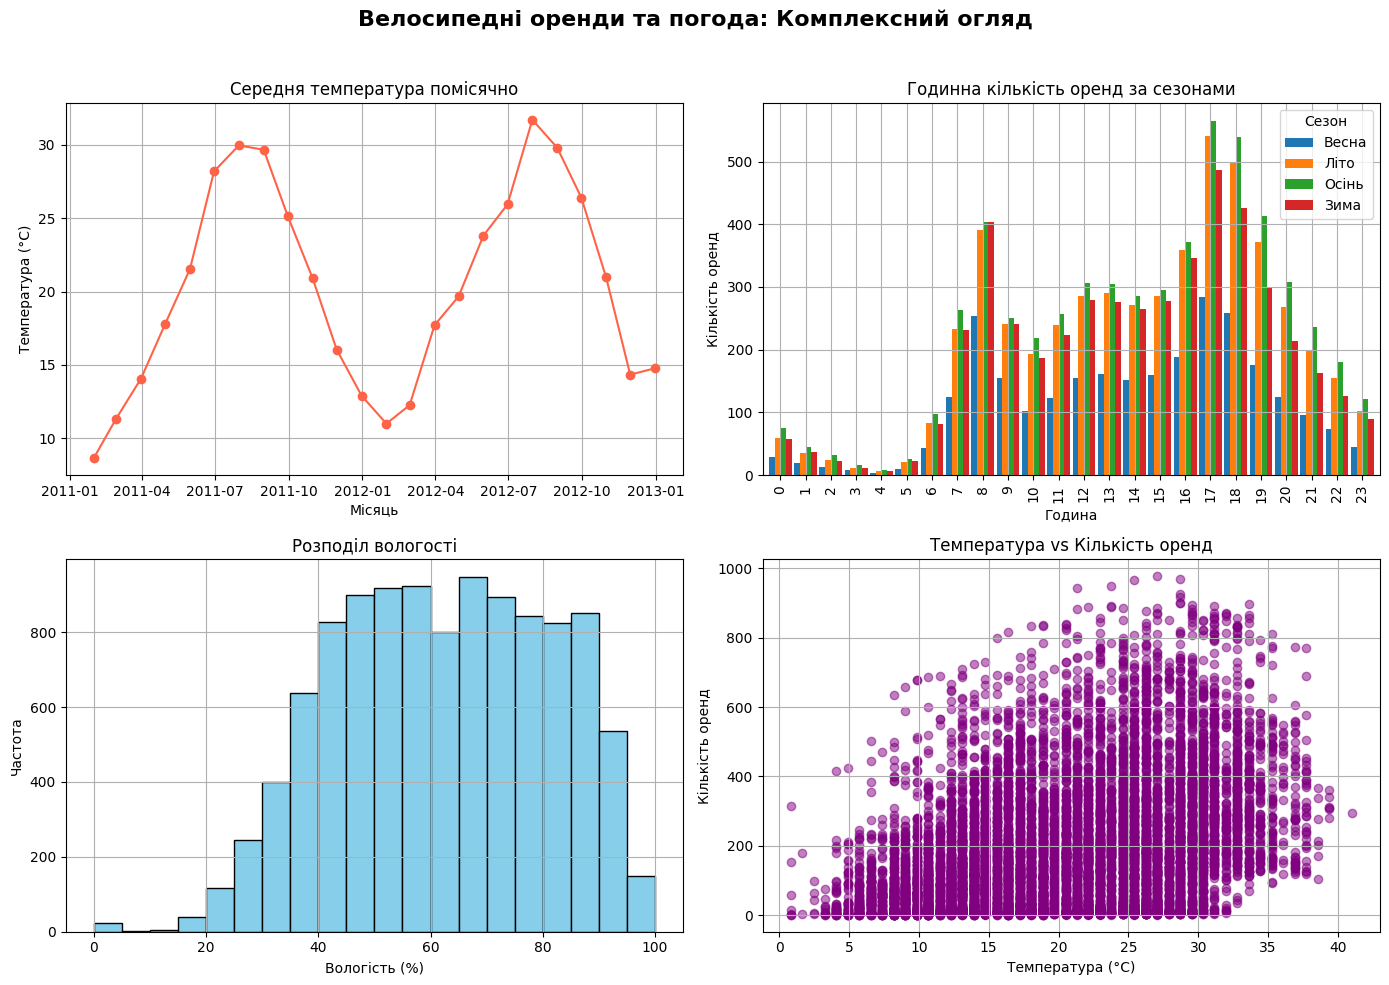

In [ ]:
import matplotlib.pyplot as plt

# Підготовка агрегованих даних
monthly_temp = df['temp'].resample('ME').mean()
seasonal_hourly_avg = df.groupby(['season', 'hour'])['count'].mean().unstack()
humidity = df['humidity']
temp_vs_rentals = df[['temp', 'count']]

# Створення сітки 2x2
plt.figure(figsize=(14, 10))
plt.suptitle('Велосипедні оренди та погода: Комплексний огляд', fontsize=16, fontweight='bold')

# 1. Лінійний графік середньої температури помісячно
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, color='tomato', marker='o')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')
plt.grid(True)

# 2. Стовпчикова діаграма середньої годинної кількості оренд за сезонами
plt.subplot(2, 2, 2)
seasonal_hourly_avg.T.plot(kind='bar', ax=plt.gca(), width=0.9)
plt.title('Годинна кількість оренд за сезонами')
plt.xlabel('Година')
plt.ylabel('Кількість оренд')
plt.legend(title='Сезон', labels=['Весна', 'Літо', 'Осінь', 'Зима'])
plt.grid(True)

# 3. Гістограма вологості
plt.subplot(2, 2, 3)
plt.hist(humidity, bins=20, color='skyblue', edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')
plt.grid(True)

# 4. Scatter plot: температура vs кількість оренд
plt.subplot(2, 2, 4)
plt.scatter(temp_vs_rentals['temp'], temp_vs_rentals['count'], alpha=0.5, color='purple')
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.grid(True)

# Показ всього дашборду
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

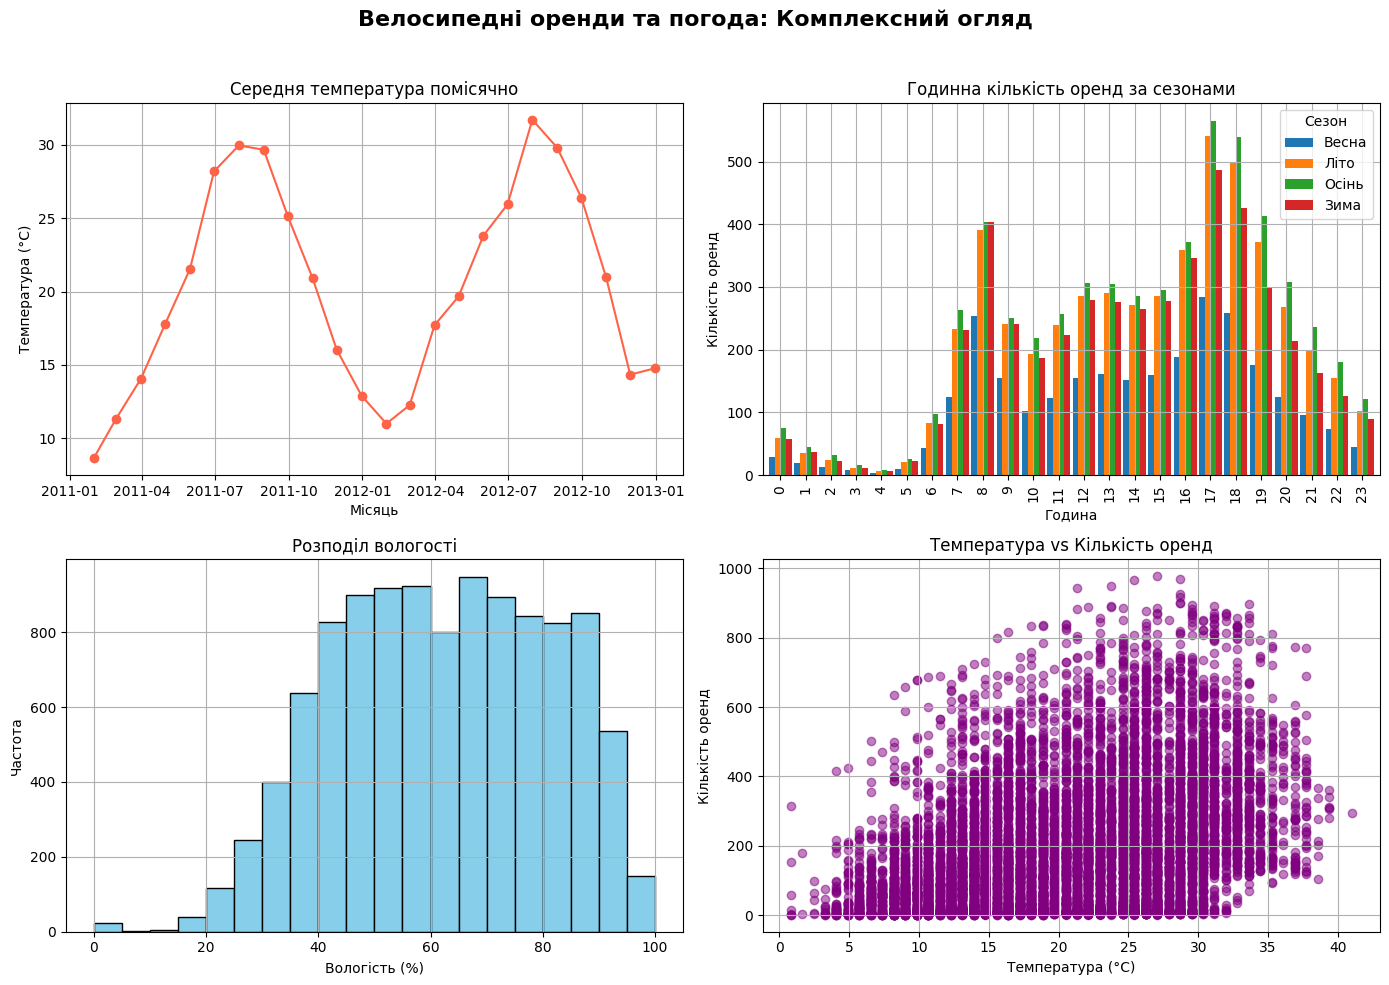

In [ ]:
import matplotlib.pyplot as plt

# Підготовка даних
monthly_temp = df['temp'].resample('ME').mean()
seasonal_hourly_avg = df.groupby(['season', 'hour'])['count'].mean().unstack()
humidity = df['humidity']
temp_vs_rentals = df[['temp', 'count']]

# Створення сітки
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Велосипедні оренди та погода: Комплексний огляд', fontsize=16, fontweight='bold')

# 1. Лінійний графік середньої температури
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, color='tomato', marker='o')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True)

# 2. Стовпчикова діаграма оренд за сезонами
seasonal_hourly_avg.T.plot(kind='bar', ax=ax[0, 1], width=0.9)
ax[0, 1].set_title('Годинна кількість оренд за сезонами')
ax[0, 1].set_xlabel('Година')
ax[0, 1].set_ylabel('Кількість оренд')
ax[0, 1].legend(title='Сезон', labels=['Весна', 'Літо', 'Осінь', 'Зима'])
ax[0, 1].grid(True)

# 3. Гістограма вологості
ax[1, 0].hist(humidity, bins=20, color='skyblue', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')
ax[1, 0].grid(True)

# 4. Scatter plot температура vs оренди
ax[1, 1].scatter(temp_vs_rentals['temp'], temp_vs_rentals['count'], alpha=0.5, color='purple')
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True)

# Фінальне форматування
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Порівняння в методах

Обидва дозволяють створювати сітку графіків, проте мають суттєві концептуальні відмінності.

plt.subplot(): Імперативний підхід
Побудова здійснюється у формі послідовних команд.

Графіки створюються один за одним — викликаючи plt.subplot(рядок, колонка, індекс).

Менш гнучкий у структурі: важче централізовано керувати стилями чи елементами.

Добре підходить для простих задач з 2–4 графіками.


  fig, ax = plt.subplots(): Об'єктно-орієнтований підхід
Повертає об'єкти: фігуру (fig) і масив осей (ax) — що дозволяє тонко керувати кожним підграфіком.

Краще підходить для:
Створення дашбордів,
Циклічної побудови графіків,
Комбінування стилів,
Додавання спільної легенди, grid, фільтрів тощо.
Код структурований, легше читається та підтримується в проєктах.

Таким чином, plt.subplots() є переважним методом для побудови професійних візуалізацій, особливо коли потрібно поєднати аналітичну чіткість і презентаційну якість



## Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

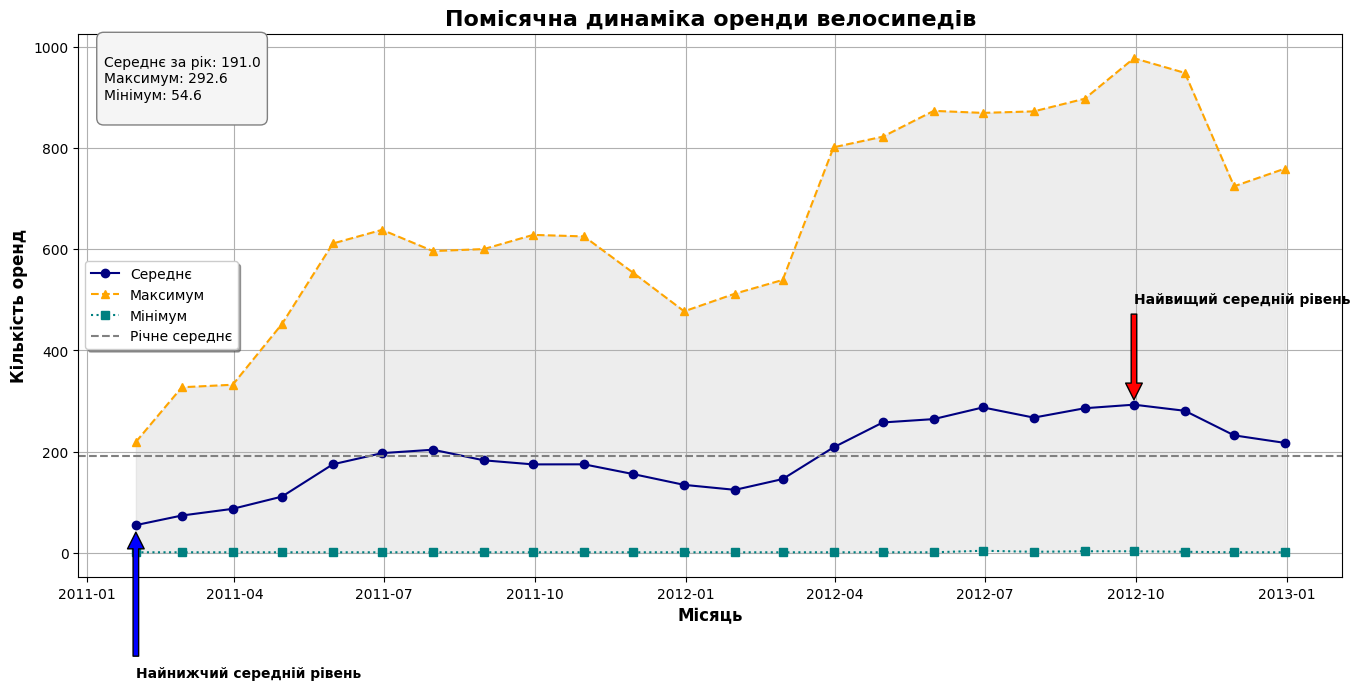

In [ ]:
# Агрегуємо щомісячні дані
monthly_group = df['count'].resample('ME')

monthly_avg = monthly_group.mean()
monthly_min = monthly_group.min()
monthly_max = monthly_group.max()

# Загальні статистики
overall_mean = monthly_avg.mean()
highest_month = monthly_avg.idxmax()
lowest_month = monthly_avg.idxmin()

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Помісячна динаміка оренди велосипедів', fontsize=16, fontweight='bold')

# Лінії з різними стилями
ax.plot(monthly_avg.index, monthly_avg.values, linestyle='-', marker='o', color='navy', label='Середнє')
ax.plot(monthly_max.index, monthly_max.values, linestyle='--', marker='^', color='orange', label='Максимум')
ax.plot(monthly_min.index, monthly_min.values, linestyle=':', marker='s', color='teal', label='Мінімум')

# Заповнення між min і max
ax.fill_between(monthly_avg.index, monthly_min, monthly_max, color='lightgray', alpha=0.4)

# Горизонтальна лінія середнього за рік
ax.axhline(overall_mean, linestyle='--', color='gray', label='Річне середнє')

# Анотації
ax.annotate('Найвищий середній рівень', xy=(highest_month, monthly_avg.max()),
            xytext=(highest_month, monthly_avg.max()+200),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=10, fontweight='bold')

ax.annotate('Найнижчий середній рівень', xy=(lowest_month, monthly_avg.min()),
            xytext=(lowest_month, monthly_avg.min()-300),
            arrowprops=dict(facecolor='blue', shrink=0.05),
            fontsize=10, fontweight='bold')

# Текстовий блок зі статистикою
stats_text = f"""
Середнє за рік: {overall_mean:.1f}
Максимум: {monthly_avg.max():.1f}
Мінімум: {monthly_avg.min():.1f}
"""
ax.text(0.02, 0.85, stats_text, transform=ax.transAxes,
        bbox=dict(facecolor='whitesmoke', edgecolor='gray', boxstyle='round,pad=0.5'),
        fontsize=10, fontweight='medium')

# Оформлення
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=12, fontweight='bold')
ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', linewidth=0.5)
ax.legend(frameon=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()